# Assembling and ranking data for the DE Africa drought monitoring

* **Products used:** 

## Background
Ranking of drought monitoring variables prior to principal component analysis as per Guillory et al. 2023.

## Description
Loading and ranking data for drought monitoring.

1. Load and rank standardised precipitation index (SPI) using CHIRPS.
2. Load and rank soil moisture.
3. Load and rank monthly NDVI.
4. Load and rank reference ET.

***

## Getting started

Provide any particular instructions that the user might need, e.g. To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

### Load packages
Import Python packages that are used for the analysis.

Use standard import commands; some are shown below. 
Begin with any `iPython` magic commands, followed by standard Python packages, then any additional functionality you need from the `Tools` package.

In [40]:
%matplotlib inline

import datacube
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray
import os
import requests
import matplotlib.pyplot as plt

from wapordl import wapor_map
from deafrica_tools.load_wapor import load_wapor_ds
from odc.geo import Geometry, CRS
from scipy import stats

### Connect to the datacube

Connect to the datacube so we can access DE Africa data.
The `app` parameter is a unique name for the analysis which is based on the notebook file name.

In [18]:
dc = datacube.Datacube(app='DroughtData')

### Analysis parameters

We will focus on a part of Zambia for this demonstration. We've loaded the Zambia .gpkg from [GADM](https://gadm.org/index.html) into our `../data` directory.


In [19]:
zmb = gpd.read_file('data/Zambia/gadm41_ZMB.gpkg', layer = 'ADM_ADM_0')

zmb

,GID_0,COUNTRY,geometry
0,ZMB,Zambia,"MULTIPOLYGON (((25.87834 -17.97218, 25.87034 -..."


In [20]:
geom = Geometry(geom=zmb.geometry.union_all(), crs=zmb.crs)

## Load CHIRPS Monthly Rainfall Data

Load monthly rainfall.

In [21]:
time_m = ('2018', '2025')

# CHIRPS has a spatial resolution of ~5x5 km
resolution = (-5000, 5000)

#size of dask chunks
dask_chunks = dict(x=500,y=500, time = -1)

query = {'geopolygon': geom,
         'time': time_m,
         'output_crs': 'epsg:6933',
         'resolution': resolution,
         'measurements': ['rainfall'],
         'dask_chunks':dask_chunks
        }

ds_rf = dc.load(product='rainfall_chirps_monthly', **query)
ds_rf

<xarray.Dataset> Size: 20MB
Dimensions:      (time: 92, y: 244, x: 227)
Coordinates:
  * time         (time) datetime64[ns] 736B 2018-01-16T11:59:59.500000 ... 20...
  * y            (y) float64 2kB -1.052e+06 -1.058e+06 ... -2.262e+06 -2.268e+06
  * x            (x) float64 2kB 2.122e+06 2.128e+06 ... 3.248e+06 3.252e+06
    spatial_ref  int32 4B 6933
Data variables:
    rainfall     (time, y, x) float32 20MB dask.array<chunksize=(92, 244, 227), meta=np.ndarray>
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

In [22]:
# 1. Normalize the existing messy timestamps to the 1st of each month
# We overwrite the 'time' coordinate with a cleaned version
ds_rf['time'] = pd.to_datetime([
    f"{y}-{m:02d}-01" for y, m in zip(ds_rf.time.dt.year.values, ds_rf.time.dt.month.values)
])

# 2. Create target range (this now matches the '01' format exactly)
full_time_range = pd.date_range(start='2018-01-01', end='2025-12-01', freq='MS')

# 3. Reindex - since they match perfectly now, this will keep your data
# and insert NaNs only for the 4 missing months.
ds_full = ds_rf.reindex(time=full_time_range)

# 4. Fill the 4 missing gaps
ds_interpolated = ds_full.interpolate_na(dim='time', method='linear')

# Optional: verify you now have 372 slices
print(len(ds_interpolated.time))

96


In [23]:
gdf = gpd.read_file('data/Zambia/gadm41_ZMB.gpkg', layer = 'ADM_ADM_1')

results = []

for index, row in gdf.iterrows():
    # 1. Mask the DataCube dataset to the current geometry
    # We use 'geometry' to clip the data to the specific polygon
    ds_feature = ds_interpolated.rio.clip([row.geometry], gdf.crs)
    
    # 2. Reduce spatially (Mean) to get a 1D timeseries
    # This collapses 'x' and 'y' dimensions
    ts_feature = ds_feature.rainfall.where(ds_feature.rainfall > -9999).mean(dim=['x', 'y']).compute()
    
    # 3. Convert to a Pandas Series or store in a list
    ts_series = ts_feature.to_series()
    ts_series.name = row['NAME_1']
    
    results.append(ts_series)

# Combine all timeseries into a single DataFrame
df_final = pd.concat(results, axis=1)

In [24]:
df_final

,Central,Copperbelt,Eastern,Luapula,Lusaka,Muchinga,North-Western,Northern,Southern,Western
time,,,,,,,,,,
2018-01-01,81.893494,130.014664,120.749001,191.588333,64.381470,187.476822,166.416901,233.268814,71.932434,84.417854
2018-02-01,312.067474,336.068634,240.376587,254.308777,326.960999,213.893951,296.340393,196.185654,384.555908,262.009705
2018-03-01,177.572327,274.433746,172.519196,235.342438,132.448135,183.226074,213.749329,233.180710,135.423157,225.483276
2018-04-01,25.495869,45.434532,43.830597,134.467728,11.598530,80.699219,76.423599,161.559509,21.575706,66.730988
2018-05-01,7.786903,6.878817,5.273947,9.165195,11.945637,6.978675,6.152216,9.444130,7.630708,3.777217
...,...,...,...,...,...,...,...,...,...,...
2025-08-01,0.375310,0.312278,0.262998,0.496473,0.363081,0.325278,0.695694,0.465959,0.153643,0.264679
2025-09-01,1.513265,1.524213,1.019324,3.843201,1.130087,1.180800,6.991456,3.464504,2.056783,4.013654
2025-10-01,7.260383,8.118386,6.863963,17.414698,5.073830,8.579893,24.266310,17.181805,10.432342,15.623535


In [25]:
def compute_seasonal_spi(df, scale=3):
    # 1. Calculate rolling sums first (still needs the full sequence)
    df_rolling = df.rolling(window=scale, min_periods=scale).sum()
    
    # Create an empty dataframe for results
    spi_results = pd.DataFrame(index=df.index, columns=df.columns)
    
    # 2. Iterate through each month (1 through 12)
    for month in range(1, 13):
        # Extract all instances of this specific month (e.g., every January)
        month_mask = df_rolling.index.month == month
        month_data = df_rolling[month_mask]
        
        # 3. Apply the Gamma fit for each attribute (column) for THIS month only
        for col in df.columns:
            series = month_data[col].dropna()
            
            if len(series) < 2: # Need at least a few years to fit
                continue
                
            # Fit and transform
            fit_shape, fit_loc, fit_scale = stats.gamma.fit(series, floc=0)
            gamma_cdf = stats.gamma.cdf(series, fit_shape, fit_loc, fit_scale)
            
            # Use a small epsilon to avoid -inf from cdf=0 or +inf from cdf=1
            gamma_cdf = np.clip(gamma_cdf, 0.001, 0.999)
            spi_values = stats.norm.ppf(gamma_cdf)
            
            # Place results back in the correct time slots
            spi_results.loc[series.index, col] = spi_values
            
    return spi_results.astype(float)

# Run the seasonally adjusted calculation
df_spi_seasonal = compute_seasonal_spi(df_final, scale=3)

df_spi_seasonal

,Central,Copperbelt,Eastern,Luapula,Lusaka,Muchinga,North-Western,Northern,Southern,Western
time,,,,,,,,,,
2018-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01,0.206062,0.351452,-0.627487,-0.353565,0.405983,-0.757377,0.457534,-0.799150,1.279624,0.793851
2018-04-01,1.558538,1.508447,0.821687,0.984138,1.630867,0.075984,1.136676,-0.360961,2.008031,1.525714
2018-05-01,1.652447,1.444367,0.742807,0.842628,1.689599,0.343962,0.627207,0.540270,1.987028,1.387930
...,...,...,...,...,...,...,...,...,...,...
2025-08-01,-0.488722,-0.601071,-0.511354,-0.570650,-0.518620,-0.686014,-0.538388,-0.499292,-0.397673,-0.416624
2025-09-01,0.235736,-0.646797,-0.193768,-0.855729,-0.374341,-0.623662,0.189839,-0.836257,0.708188,1.376486
2025-10-01,-0.577193,-0.822020,-0.672695,-1.253148,-0.538706,-0.472897,-1.147911,-0.627739,0.388086,-0.170822


### Rank percentile

In [26]:
df_rainfall_percentile = df_spi_seasonal.groupby(df_spi_seasonal.index.month).rank(pct=True)

df_rainfall_percentile

,Central,Copperbelt,Eastern,Luapula,Lusaka,Muchinga,North-Western,Northern,Southern,Western
time,,,,,,,,,,
2018-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01,0.500,0.750,0.375,0.500,0.625,0.375,0.750,0.375,1.000,0.750
2018-04-01,1.000,1.000,0.875,0.875,1.000,0.500,0.875,0.625,1.000,1.000
2018-05-01,1.000,0.875,0.750,0.875,1.000,0.500,0.750,0.750,1.000,1.000
...,...,...,...,...,...,...,...,...,...,...
2025-08-01,0.250,0.125,0.500,0.125,0.250,0.125,0.375,0.250,0.750,0.625
2025-09-01,0.875,0.375,0.625,0.250,0.625,0.125,0.625,0.250,0.875,0.875
2025-10-01,0.500,0.250,0.250,0.250,0.500,0.500,0.250,0.375,0.750,0.500


## Repeat for soil moisture
Get the data for soil moisture and percentile rank it.

In [28]:
opendap_url = "https://psl.noaa.gov/thredds/dodsC/Datasets/cpcsoil/soilw.mon.mean.v2.nc"

# Open the dataset lazily (this takes less than a second)
# chunks={} tells xarray to optimize data streaming via Dask if available
ds = xr.open_dataset(opendap_url, chunks={})

# Print metadata to inspect coordinates (time, lat, lon) and variables
ds

<xarray.Dataset> Size: 976MB
Dimensions:  (time: 941, lat: 360, lon: 720)
Coordinates:
  * time     (time) datetime64[ns] 8kB 1948-01-01 1948-02-01 ... 2026-05-01
  * lat      (lat) float32 1kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float32 3kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
Data variables:
    soilw    (time, lat, lon) float32 976MB dask.array<chunksize=(941, 360, 720), meta=np.ndarray>
Attributes:
    _NCProperties:                   version=1|netcdflibversion=4.4.1.1|hdf5l...
    Conventions:                     CF-1.0
    title:                           CPC Soil Moisture
    institution:                     NOAA/ESRL PSD
    dataset_title:                   CPC Soil Moisture
    history:                         Wed Oct 18 15:13:37 2017: ncks -d time,,...
    NCO:                             4.6.9
    References:                      https://www.psl.noaa.gov/data/gridded/da...
    source:                          https://www.cpc.ncep.noaa.gov/products/S...
    DODS_EXTRA.Unlimited_Dimension:  time

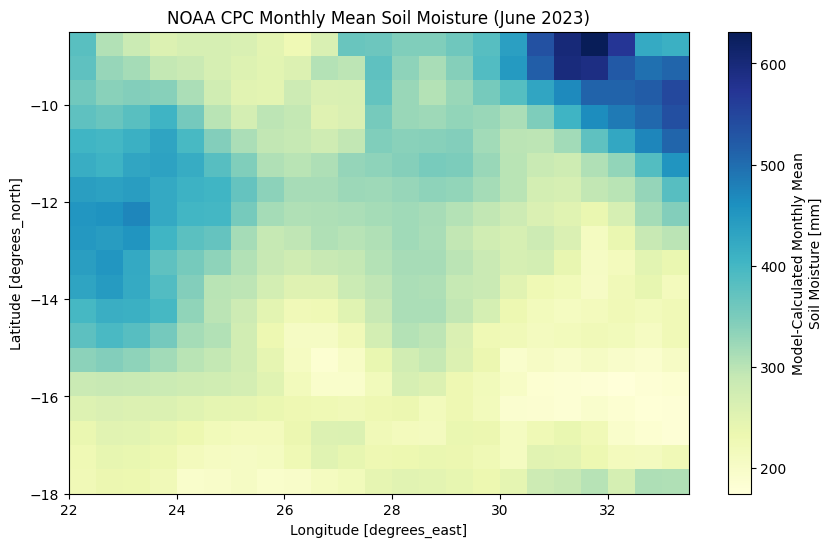

In [35]:
zmb_sm = ds['soilw'].sel(
    time=slice("2018-01-01", "2026-12-31"),
    lat=slice(zmb.total_bounds[3], zmb.total_bounds[1]),  # Slicing from North to South depending on grid orientation
    lon=slice(zmb.total_bounds[0], zmb.total_bounds[2])
)

# 4. Trigger the actual data stream by plotting or computing
plt.figure(figsize=(10, 6))
zmb_sm.isel(time=0).plot(cmap="YlGnBu")
plt.title("NOAA CPC Monthly Mean Soil Moisture (June 2023)")
plt.show()

## Repeat for Reference ET
Get the data for soil moisture and percentile rank it.

In [38]:
folder = "data/WaPOR" # folder that the data will be sent to
variable = "L1-RET-M" # level-variable-time, see table above
period = ["2018-01-01", "2024-02-01"] # period to load

region = [zmb.total_bounds[0], zmb.total_bounds[1], zmb.total_bounds[2], zmb.total_bounds[3]]

In [41]:
ret = wapor_map(region, variable, period, folder, extension = '.nc')

ret_xr = load_wapor_ds(filename=ret, variable=variable)

ret_xr

INFO: Found 74 files for L1-RET-M.
INFO: Converting from `.tif` to `.nc`.


<xarray.Dataset> Size: 901kB
Dimensions:      (x: 38, y: 40, time: 74)
Coordinates:
  * x            (x) float64 304B 22.03 22.34 22.66 22.97 ... 32.97 33.28 33.59
  * y            (y) float64 320B -8.375 -8.625 -8.875 ... -17.62 -17.88 -18.12
  * time         (time) datetime64[ns] 592B 2018-01-01 2018-02-01 ... 2024-02-01
    spatial_ref  int32 4B 4326
Data variables:
    L1-RET-M     (time, y, x) float64 900kB 113.2 113.9 111.3 ... -999.9 -999.9
Attributes: (12/13)
    lat#long_name:        latitude
    lat#standard_name:    latitude
    lat#units:            degrees_north
    lon#long_name:        longitude
    lon#standard_name:    longitude
    lon#units:            degrees_east
    ...                   ...
    overview:             NONE
    temporal_resolution:  Month
    units:                mm/month
    scale_factor:         0.1
    _FillValue:           -9999
    add_offset:           0.0

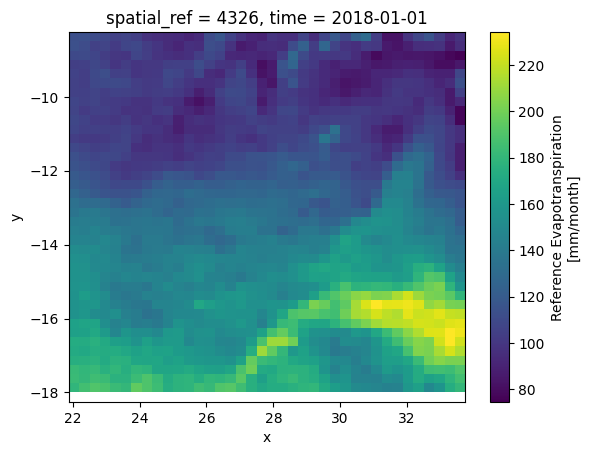

In [46]:
ret_xr.where(ret_xr['L1-RET-M'] > -999)[variable].isel(time=0).plot()

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Slack channel](http://slack.opendatacube.org/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

**Compatible datacube version:** 

In [ ]:
print(datacube.__version__)

**Last Tested:**

In [ ]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')